In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn

!pip install pennylane pennylane-lightning --upgrade -q
sns.set_style("whitegrid")
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")






     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.0 MB/s eta 0:00:00
device: cuda


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/quantum-sentinel"
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

import scripts

print("scripts loaded from:", scripts.__file__)

scripts loaded from: /content/drive/MyDrive/quantum-sentinel/scripts/__init__.py


In [ ]:


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from scripts.cache import (
    ForwardCache,
    cached_calibrate_threshold,
    cached_conformal_alpha_sweep,
    cached_nonconformity_scores,
    cached_predict_labels,
    cached_qsnet_infer,
    cached_qsnet_infer_per_class,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.conformal import (
    min_calibration_size,
    threshold_from_scores,
)
from scripts.constants import (
    DEFAULT_ALPHA,
    DEFAULT_CF,
    DEFAULT_NOISE_RATE,
    DEFAULT_REUPLOAD,
    ZERO_DAY,
)
from scripts.data import (
    capped_sample,
    greedy_dpp_sample,
    load_split,
    to_angles,
)
from scripts.theory import analytic_lipschitz_bound, clopper_pearson_ci

DATA_DIR = f"{PROJECT_DIR}/data/FROZEN/BOT-IOT"
SAVED_MODEL_PATH = f"{PROJECT_DIR}/models/prototypes/BOT-IOT/23.maqt-FROZEN-feat-prototypes_bot-iot-checkpoint.pt"
CACHE_OUTPUT_DIR = f"{PROJECT_DIR}/caches/BOT-IOT"
Path(CACHE_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

In [ ]:
print("="*60); print("LOADING CHECKPOINT"); print("="*60)
assert Path(SAVED_MODEL_PATH).exists(), f"Not found: {SAVED_MODEL_PATH}"

ckpt = torch.load(SAVED_MODEL_PATH, map_location="cpu", weights_only=False)

theta_star       = ckpt["theta"]
head_state_dict  = ckpt["head_state_dict"]
prototypes_raw   = ckpt["prototypes"]
class_names      = ckpt["class_names"]
num_classes      = ckpt["num_classes"]
num_qubits       = ckpt["num_qubits"]
num_layers       = ckpt["num_layers"]
noise_rate       = ckpt.get("noise_rate", DEFAULT_NOISE_RATE)
reupload         = ckpt.get("reupload", DEFAULT_REUPLOAD)
feature_cols     = ckpt["feature_cols"]
use_pca          = ckpt.get("use_pca", True)
target_col       = ckpt["target_col"]

scaler       = ckpt["scaler"]
pca          = ckpt.get("pca", None)
angle_x_min  = np.asarray(ckpt["angle_x_min"])
angle_x_max  = np.asarray(ckpt["angle_x_max"])
angle_max    = ckpt.get("angle_max", float(np.pi))

SUBSET        = ckpt.get("subset", True)
PER_CLASS_CAP = ckpt.get("per_class_cap", 3000)
SAMPLER       = ckpt.get("sampler", "greedy_dpp")


prototypes = {int(k): (v if torch.is_tensor(v) else torch.tensor(v)).to(DEVICE)
              for k, v in prototypes_raw.items()}

print(f" classes   : {class_names}")
print(f" qubits    : {num_qubits}  layers: {num_layers}  reupload: {reupload}  noise: {noise_rate}")
print(f" theta     : {tuple(theta_star.shape)}")
print(f" prototypes: {len(prototypes)} classes")


classifier_head = nn.Linear(num_qubits, num_classes).to(DEVICE)
classifier_head.load_state_dict(head_state_dict)
classifier_head.eval()
print(f" head      : Linear({num_qubits} -> {num_classes}) loaded OK")

LOADING CHECKPOINT
 classes   : ['DDoS', 'DoS', 'Normal', 'Reconnaissance']
 qubits    : 5  layers: 2  reupload: True  noise: 0.01
 theta     : (2, 5, 3)
 prototypes: 4 classes
 head      : Linear(5 -> 4) loaded OK


In [ ]:
print("="*60); print("LOADING RAW DATA SPLITS"); print("="*60)

X_train_full, y_train_full, _ = load_split(DATA_DIR, "train", target_col, csv=True, selected_cols=feature_cols)
X_test,       y_test,       _ = load_split(DATA_DIR, "test",  target_col, csv=True, selected_cols=feature_cols)
X_cal,        y_cal,        _ = load_split(DATA_DIR, "calibration", target_col, csv=True, selected_cols=feature_cols)
X_zeroday,    y_zeroday,    _ = load_split(DATA_DIR, "zeroday", target_col, csv=True, selected_cols=feature_cols)

print(f" train(full): {X_train_full.shape}  test: {X_test.shape}  cal: {X_cal.shape}  zeroday: {X_zeroday.shape}")


if SUBSET and SAMPLER == "greedy_dpp":
    X_train, y_train = greedy_dpp_sample(X_train_full, y_train_full, per_class_cap=PER_CLASS_CAP, seed=SEED)
elif SUBSET:
    X_train, y_train = capped_sample(X_train_full, y_train_full, per_class_cap=PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full
print(f" train(subset): {X_train.shape} via {SAMPLER}")


def encode(X):
    return to_angles(X, scaler, angle_x_min, angle_x_max,
                      pca=pca if use_pca else None, angle_max=angle_max)

A_train, A_test, A_cal, A_zeroday = encode(X_train), encode(X_test), encode(X_cal), encode(X_zeroday)
print(f" A_train {A_train.shape}  A_test {A_test.shape}  A_cal {A_cal.shape}  A_zeroday {A_zeroday.shape}")

LOADING RAW DATA SPLITS
 train(full): (148729, 10)  test: (18591, 10)  cal: (18591, 10)  zeroday: (683, 10)
 train(subset): (11832, 10) via greedy_dpp
 A_train (11832, 5)  A_test (18591, 5)  A_cal (18591, 5)  A_zeroday (683, 5)


In [ ]:
print("="*60); print("QUANTUM CIRCUIT"); print("="*60)

dev = create_quantum_device(num_qubits)  # default.mixed
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers,
                                         noise_rate=noise_rate, reupload=reupload)
theta_device = theta_star.to(DEVICE)
print(f" device={DEVICE}  qml wires={num_qubits}  theta on {theta_device.device}")

print("\n" + "="*60); print("BUILDING FORWARD CACHE"); print("="*60)
cache = ForwardCache(store_device="cpu")

splits = [("train", A_train), ("test", A_test), ("cal", A_cal), ("zeroday", A_zeroday)]
t0 = time.time()
for key, A in splits:
    entry = cache.compute(key, A, theta_device, forward_circuit, device=DEVICE, batch_size=128, p=noise_rate)
    mb = (entry["rho"].numel()*entry["rho"].element_size() + entry["z"].numel()*entry["z"].element_size()) / 1e6
    print(f" [{key:8s}] n={entry['n']:>7,}  rho={tuple(entry['rho'].shape)}  z={tuple(entry['z'].shape)}  {mb:.1f} MB")
print(f"total: {time.time()-t0:.1f}s")

QUANTUM CIRCUIT
 device=cuda  qml wires=5  theta on cuda:0

BUILDING FORWARD CACHE
 [train   ] n= 11,832  rho=(11832, 32, 32)  z=(11832, 5)  194.1 MB
 [test    ] n= 18,591  rho=(18591, 32, 32)  z=(18591, 5)  305.0 MB
 [cal     ] n= 18,591  rho=(18591, 32, 32)  z=(18591, 5)  305.0 MB
 [zeroday ] n=    683  rho=(683, 32, 32)  z=(683, 5)  11.2 MB
total: 38.5s


In [ ]:
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
cache_path = Path(CACHE_OUTPUT_DIR) / f"forward_cache_{ts}.pt"

save_dict = {
    "timestamp": ts, "checkpoint_src": str(SAVED_MODEL_PATH),
    "num_qubits": num_qubits, "num_layers": num_layers, "noise_rate": noise_rate, "reupload": reupload,
    "feature_cols": feature_cols, "class_names": class_names, "num_classes": num_classes,
    "target_col": target_col, "use_pca": use_pca,
    "angle_x_min": angle_x_min, "angle_x_max": angle_x_max, "angle_max": angle_max,
    "subset": SUBSET, "per_class_cap": PER_CLASS_CAP, "sampler": SAMPLER, "seed": SEED,
}
for key in ("train", "test", "cal", "zeroday"):
    entry = cache.get(key)
    save_dict[f"{key}_z"]   = entry["z"]
    save_dict[f"{key}_rho"] = entry["rho"]
    save_dict[f"{key}_n"]   = entry["n"]

torch.save(save_dict, cache_path)
latest = Path(CACHE_OUTPUT_DIR) / "forward_cache_latest.pt"
if latest.exists() or latest.is_symlink(): latest.unlink()
latest.symlink_to(cache_path.name)
print(f"saved: {cache_path}  ({cache_path.stat().st_size/1e6:.1f} MB)")

saved: /content/drive/MyDrive/quantum-sentinel/caches/BOT-IOT/forward_cache_20260802_141624.pt  (815.2 MB)


In [ ]:
print("="*60); print("RELOADING CACHE & CHECKPOINT"); print("="*60)

cache_data = torch.load(Path(CACHE_OUTPUT_DIR) / "forward_cache_latest.pt", map_location="cpu", weights_only=False)

def entry_from_disk(key):
    return {"z": cache_data[f"{key}_z"].to(DEVICE),
            "rho": cache_data[f"{key}_rho"].to(DEVICE),
            "n": cache_data[f"{key}_n"]}

test_entry = entry_from_disk("test")
cal_entry  = entry_from_disk("cal")
zday_entry = entry_from_disk("zeroday")

ckpt = torch.load(SAVED_MODEL_PATH, map_location="cpu", weights_only=False)
classifier_head = nn.Linear(cache_data["num_qubits"], cache_data["num_classes"]).to(DEVICE)
classifier_head.load_state_dict(ckpt["head_state_dict"])
classifier_head.eval()

prototypes = {int(k): (v if torch.is_tensor(v) else torch.tensor(v)).to(DEVICE)
              for k, v in ckpt["prototypes"].items()}
class_names = cache_data["class_names"]
num_classes = cache_data["num_classes"]
num_layers  = cache_data["num_layers"]
noise_rate  = cache_data["noise_rate"]
reupload    = cache_data["reupload"]

print(f" reloaded test n={test_entry['n']:,}  cal n={cal_entry['n']:,}  zeroday n={zday_entry['n']:,}")

RELOADING CACHE & CHECKPOINT
 reloaded test n=18,591  cal n=18,591  zeroday n=683


TEST SET EVALUATION
Test accuracy: 0.5745
                precision    recall  f1-score   support

          DDoS       0.58      0.71      0.64      9411
           DoS       0.58      0.37      0.45      8135
        Normal       0.45      0.96      0.61       691
Reconnaissance       0.70      0.95      0.81       354

      accuracy                           0.57     18591
     macro avg       0.58      0.75      0.63     18591
  weighted avg       0.58      0.57      0.56     18591



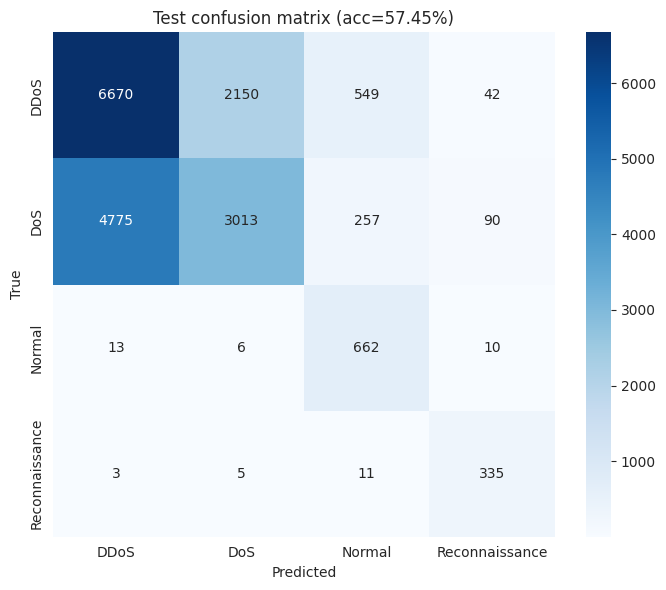

In [ ]:
print("="*60); print("TEST SET EVALUATION"); print("="*60)

y_true_test, y_pred_test = cached_predict_labels(test_entry, y_test, classifier_head, device=DEVICE, batch_size=1024)

test_acc = accuracy_score(y_true_test, y_pred_test)
print(f"Test accuracy: {test_acc:.4f}")
print(classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true_test, y_pred_test, labels=range(num_classes))
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Test confusion matrix (acc={test_acc:.2%})")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout(); plt.show()

In [ ]:
L_PHI = analytic_lipschitz_bound(num_layers, reupload=reupload)
print(f"L_phi (analytic, Lemma 1) = R/2 = {num_layers}/2 = {L_PHI:.4f}  (reupload={reupload})")

L_phi (analytic, Lemma 1) = R/2 = 2/2 = 1.0000  (reupload=True)


In [ ]:
print("="*60); print("GLOBAL CONFORMAL CALIBRATION"); print("="*60)

n_cal = cal_entry["n"]
print(f"min calibration size for alpha={DEFAULT_ALPHA}: n >= {min_calibration_size(DEFAULT_ALPHA):.1f} (have {n_cal})")

q_global, cal_scores_sorted = cached_calibrate_threshold(cal_entry, prototypes, alpha=DEFAULT_ALPHA,
                                                          device=DEVICE, batch_size=256)
print(f"Global threshold q = {q_global:.4f}")

alphas = (0.01, 0.05, 0.1, 0.2)
feasible_alphas = [a for a in alphas if n_cal >= min_calibration_size(a)]
alpha_rows = cached_conformal_alpha_sweep(cal_entry, test_entry, prototypes,
                                           alphas=feasible_alphas, device=DEVICE, batch_size=256)
df_alpha = pd.DataFrame(alpha_rows)
df_alpha

GLOBAL CONFORMAL CALIBRATION
min calibration size for alpha=0.05: n >= 19.0 (have 18591)
Global threshold q = 0.1095


,alpha,q,empirical_false_alarm_rate,min_calibration_size,n_cal
0,0.01,0.402528,0.009198,99.0,18591
1,0.05,0.109523,0.047442,19.0,18591
2,0.10,0.096437,0.098489,9.0,18591
3,0.20,0.081756,0.195794,4.0,18591


In [ ]:

def cached_class_conditional_calibrate(entry, y_cal, prototypes, alpha=DEFAULT_ALPHA,
                                        device=None, batch_size=256, fallback="global"):
    """Cached variant of conformal.class_conditional_calibrate() -- no circuit calls."""
    y_cal = np.asarray(y_cal)
    class_ids = sorted(prototypes.keys())
    global_scores = cached_nonconformity_scores(entry, prototypes, device=device, batch_size=batch_size)
    global_q, _ = threshold_from_scores(global_scores, alpha=alpha)

    q_by_class, meta = {}, {}
    for c in class_ids:
        mask = (y_cal == c)
        n_c = int(mask.sum())
        class_scores = global_scores[mask]
        try:
            q_c, _ = threshold_from_scores(class_scores, alpha=alpha)
            meta[c] = {"n": n_c, "status": "ok", "q": q_c}
            q_by_class[c] = q_c
        except ValueError as e:
            if fallback == "abstain":
                raise ValueError(f"Class {c}: {e}") from e
            meta[c] = {"n": n_c, "status": "insufficient -- used GLOBAL threshold", "q": global_q}
            q_by_class[c] = global_q
    meta["_global"] = {"q": global_q, "n": len(global_scores), "status": "marginal"}
    return q_by_class, meta

q_by_class, calib_meta = cached_class_conditional_calibrate(
    cal_entry, y_cal, prototypes, alpha=DEFAULT_ALPHA, device=DEVICE, batch_size=256, fallback="global"
)
print("Per-class thresholds:")
for c in sorted(prototypes.keys()):
    m = calib_meta[c]
    print(f"  {class_names[c]:15s} n={m['n']:5d}  q={m['q']:.4f}  status={m['status']}")
print(f"  global (marginal) q = {calib_meta['_global']['q']:.4f}")

Per-class thresholds:
  DDoS            n= 9411  q=0.1032  status=ok
  DoS             n= 8135  q=0.0982  status=ok
  Normal          n=  691  q=0.4727  status=ok
  Reconnaissance  n=  354  q=0.1720  status=ok
  global (marginal) q = 0.1095


In [ ]:
def cached_per_class_far(entry, y_known, prototypes, q_by_class_map, device=None, batch_size=256):
    y_known = np.asarray(y_known)
    scores = cached_nonconformity_scores(entry, prototypes, device=device, batch_size=batch_size)
    rows = []
    for c in sorted(prototypes.keys()):
        mask = y_known == c
        n_c = int(mask.sum())
        far_c = float(np.mean(scores[mask] > q_by_class_map[c])) if n_c else float("nan")
        rows.append({"class": c, "n": n_c, "q": q_by_class_map[c], "empirical_far": far_c})
    return rows

q_global_map = {c: q_global for c in prototypes}
far_global   = cached_per_class_far(test_entry, y_test, prototypes, q_global_map, device=DEVICE, batch_size=256)
far_perclass = cached_per_class_far(test_entry, y_test, prototypes, q_by_class,   device=DEVICE, batch_size=256)

df_far = pd.DataFrame([
    {"class": class_names[r["class"]], "n": r["n"],
     "FAR_global": r["empirical_far"], "FAR_mondrian": r2["empirical_far"]}
    for r, r2 in zip(far_global, far_perclass)
])
df_far["abs_dev_global"]   = (df_far["FAR_global"]   - DEFAULT_ALPHA).abs()
df_far["abs_dev_mondrian"] = (df_far["FAR_mondrian"] - DEFAULT_ALPHA).abs()
print(f"FAR spread  global={df_far['FAR_global'].max()-df_far['FAR_global'].min():.4f}  "
      f"mondrian={df_far['FAR_mondrian'].max()-df_far['FAR_mondrian'].min():.4f}")
df_far

FAR spread  global=0.3345  mondrian=0.0155


,class,n,FAR_global,FAR_mondrian,abs_dev_global,abs_dev_mondrian
0,DDoS,9411,0.043991,0.052173,0.006009,0.002173
1,DoS,8135,0.021512,0.045237,0.028488,0.004763
2,Normal,691,0.356006,0.060781,0.306006,0.010781
3,Reconnaissance,354,0.132768,0.048023,0.082768,0.001977


In [ ]:
print("="*60); print("ZERO-DAY DETECTION: GLOBAL vs MONDRIAN"); print("="*60)

# --- Global threshold ---
labels_zday_g, radii_zday_g, scores_zday_g, _ = cached_qsnet_infer(
    zday_entry, prototypes, q_global, p=noise_rate, L_phi=L_PHI, Cf=DEFAULT_CF,
    zero_day=ZERO_DAY, device=DEVICE, batch_size=256,
)
labels_test_g, radii_test_g, scores_test_g, _ = cached_qsnet_infer(
    test_entry, prototypes, q_global, p=noise_rate, L_phi=L_PHI, Cf=DEFAULT_CF,
    zero_day=ZERO_DAY, device=DEVICE, batch_size=256,
)
tp_g, n_g = int(np.sum(labels_zday_g == ZERO_DAY)), len(labels_zday_g)
fp_g, m_g = int(np.sum(labels_test_g == ZERO_DAY)), len(labels_test_g)
TPR_g, FPR_g = tp_g/n_g, fp_g/m_g
tpr_g_lo, tpr_g_hi = clopper_pearson_ci(tp_g, n_g)
fpr_g_lo, fpr_g_hi = clopper_pearson_ci(fp_g, m_g)

accepted_g = labels_test_g != ZERO_DAY
class_acc_g = float(np.mean(labels_test_g[accepted_g] == y_test[accepted_g]))

# --- Mondrian (per-class) threshold ---
labels_zday_pc, radii_zday_pc, scores_zday_pc, _ = cached_qsnet_infer_per_class(
    zday_entry, prototypes, q_by_class, p=noise_rate, L_phi=L_PHI, Cf=DEFAULT_CF,
    zero_day=ZERO_DAY, device=DEVICE, batch_size=256,
)
labels_test_pc, radii_test_pc, scores_test_pc, _ = cached_qsnet_infer_per_class(
    test_entry, prototypes, q_by_class, p=noise_rate, L_phi=L_PHI, Cf=DEFAULT_CF,
    zero_day=ZERO_DAY, device=DEVICE, batch_size=256,
)
tp_pc, n_pc = int(np.sum(labels_zday_pc == ZERO_DAY)), len(labels_zday_pc)
fp_pc, m_pc = int(np.sum(labels_test_pc == ZERO_DAY)), len(labels_test_pc)
TPR_pc, FPR_pc = tp_pc/n_pc, fp_pc/m_pc
tpr_pc_lo, tpr_pc_hi = clopper_pearson_ci(tp_pc, n_pc)
fpr_pc_lo, fpr_pc_hi = clopper_pearson_ci(fp_pc, m_pc)

df_comparison = pd.DataFrame([
    {"method": "Global",   "TPR": TPR_g,  "TPR_lo": tpr_g_lo,  "TPR_hi": tpr_g_hi,
     "FPR": FPR_g,  "FPR_lo": fpr_g_lo,  "FPR_hi": fpr_g_hi},
    {"method": "Mondrian", "TPR": TPR_pc, "TPR_lo": tpr_pc_lo, "TPR_hi": tpr_pc_hi,
     "FPR": FPR_pc, "FPR_lo": fpr_pc_lo, "FPR_hi": fpr_pc_hi},
])
print(f"[global]   TPR={TPR_g:.4f} (CI [{tpr_g_lo:.4f},{tpr_g_hi:.4f}])  "
      f"FPR={FPR_g:.4f} (CI [{fpr_g_lo:.4f},{fpr_g_hi:.4f}])  known-acc(accepted)={class_acc_g:.4f}")
print(f"[mondrian] TPR={TPR_pc:.4f} (CI [{tpr_pc_lo:.4f},{tpr_pc_hi:.4f}])  "
      f"FPR={FPR_pc:.4f} (CI [{fpr_pc_lo:.4f},{fpr_pc_hi:.4f}])")
df_comparison

ZERO-DAY DETECTION: GLOBAL vs MONDRIAN
[global]   TPR=0.8682 (CI [0.8405,0.8927])  FPR=0.0474 (CI [0.0444,0.0506])  known-acc(accepted)=0.6037
[mondrian] TPR=0.5988 (CI [0.5610,0.6358])  FPR=0.0649 (CI [0.0614,0.0685])


,method,TPR,TPR_lo,TPR_hi,FPR,FPR_lo,FPR_hi
0,Global,0.868228,0.840533,0.892692,0.047442,0.044431,0.050597
1,Mondrian,0.598829,0.560976,0.635823,0.064870,0.061371,0.068506


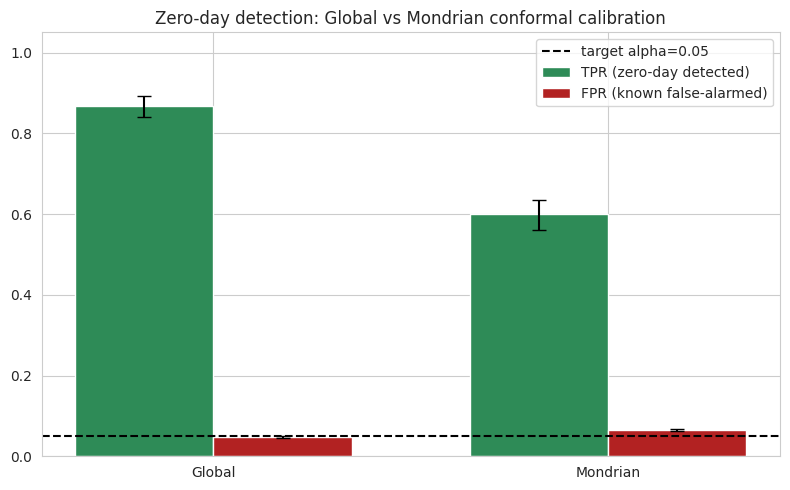

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(len(df_comparison)); width = 0.35
tpr_err = [df_comparison["TPR"]-df_comparison["TPR_lo"], df_comparison["TPR_hi"]-df_comparison["TPR"]]
fpr_err = [df_comparison["FPR"]-df_comparison["FPR_lo"], df_comparison["FPR_hi"]-df_comparison["FPR"]]
ax.bar(x-width/2, df_comparison["TPR"], width, yerr=tpr_err, capsize=5, label="TPR (zero-day detected)", color="seagreen")
ax.bar(x+width/2, df_comparison["FPR"], width, yerr=fpr_err, capsize=5, label="FPR (known false-alarmed)", color="firebrick")
ax.axhline(DEFAULT_ALPHA, color="black", linestyle="--", label=f"target alpha={DEFAULT_ALPHA}")
ax.set_xticks(x); ax.set_xticklabels(df_comparison["method"])
ax.set_ylim(0, 1.05); ax.set_title("Zero-day detection: Global vs Mondrian conformal calibration")
ax.legend(); plt.tight_layout(); plt.show()